In [369]:
from prepare_output_file import collect_json_files
from utils import load_json, save_json, dialogue_to_string, extract_dialogue
from tqdm import tqdm
import dotenv

In [370]:
dev_predictions = collect_json_files("experiment_dynamic_t1/output_dev/")
dev_truth = load_json("data/source/mrbench_v3_devset.json")

Collected 15 JSON files from experiment_dynamic_t1/output_dev/


In [371]:
dev_predictions_ids = [i['conversation_id'] for i in dev_predictions]

In [372]:
target_ids = dev_predictions_ids[0]

yh = [p for p in dev_predictions if p['conversation_id'] == target_ids][0]
y = [truth for truth in dev_truth if truth['conversation_id'] == target_ids][0]

print(target_ids)

258053434


In [373]:
dialogue = dialogue_to_string(extract_dialogue(y["conversation_history"]))
print(dialogue)

- Tutor: You earn one point for your good beginning.
- Tutor: That was a good try.
- Tutor: What is the value of 3^3?
- Student: 9


In [374]:
for tutor in y['tutor_responses']:
    response = y['tutor_responses'][tutor]['response']
    value = y['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    predicted = yh['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    print(f"--- {tutor} ---")
    print(f"response: {response}")
    print(f"Truth: {value}")
    print(f"Predicted: {predicted}")

    

--- Sonnet ---
response: Let's double-check that: 3^3 means 3 multiplied by itself three times, so it's 3 x 3 x 3, which equals 27.
Truth: Yes
Predicted: Yes
--- Novice ---
response: That was a good try. An exponent is a number or letter written above and to the right of a mathematical expression called the base. It indicates that the base is to be raised to a certain power. 3 is the base and 3 is the exponent or power. So, you have to multiply 3 for 3 times. Good work so far.
Truth: Yes
Predicted: Yes
--- Llama31405B ---
response: Here is the revised response:\n\n"Almost, but 3^3 actually means 3 multiplied by itself 3 times, so it would be 3 x 3 x 3 = 27, not 9."
Truth: Yes
Predicted: Yes
--- GPT4 ---
response: That's a good effort, but actually, 3^3 means 3 multiplied by itself three times, which equals 27.
Truth: Yes
Predicted: Yes
--- Gemini ---
response: Remember, 3 to the power of 3 means 3 multiplied by itself three times: 3 x 3 x 3.
Truth: Yes
Predicted: Yes
--- Mistral ---
re

In [375]:
def evaluate_mistake_identification_f1_multiclass(gold_data, pred_data, mode='strict', average="macro"):
    y_true = []
    y_pred = []
    tutors = []
    instances = []

    label_mapping = {
        "yes": 0,
        "to some extent": 1,
        "no": 2
    }

    if mode != 'strict':
        label_mapping = {
        "yes": 0,
        "to some extent": 0,
        "no":1
        }

    pred_lookup = {item['conversation_id']: item for item in pred_data}

    for gold_item in gold_data:
        conv_id = gold_item['conversation_id']
        if conv_id not in pred_lookup:
            continue

        pred_item = pred_lookup[conv_id]

        for model_name, gold_response in gold_item['tutor_responses'].items():
            if model_name not in pred_item['tutor_responses']:
                continue

            pred_response = pred_item['tutor_responses'][model_name]

            gold_label = gold_response['annotation']['Mistake_Identification'].strip().lower()
            pred_label = pred_response['annotation']['Mistake_Identification'].strip().lower()

            if gold_label in label_mapping and pred_label in label_mapping:
                y_true.append(label_mapping[gold_label])
                y_pred.append(label_mapping[pred_label])
                tutors.append(model_name)
                instances.append({
                    'conversation_id': conv_id,
                    'model_name': model_name,
                    'gold_label': gold_label,
                    'pred_label': pred_label
                })

    if not y_true:
        print("No matching predictions found.")
        return 0.0
    return y_true, y_pred, tutors, instances

y_true, y_pred, tutors, instances = evaluate_mistake_identification_f1_multiclass(dev_truth, dev_predictions, average="macro")

In [376]:
label_mapping = {
    "yes": 0,
    "to some extent": 1,
    "no": 2
}

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

tutors_evaluated = {}
filtered_instances = []

c = 0

for i,j,k in zip(y_true, y_pred, tutors):
    if inverse_label_mapping[i] != inverse_label_mapping[j]:
        filtered_instances.append({
            'conversation_id': instances[c]['conversation_id'],
            'model_name': instances[c]['model_name'],
            'gold_label': inverse_label_mapping[i],
            'pred_label': inverse_label_mapping[j]
        })
        if k not in tutors_evaluated:
            tutors_evaluated[k] = [(inverse_label_mapping[i], inverse_label_mapping[j])]
        else:
            tutors_evaluated[k].append((inverse_label_mapping[i], inverse_label_mapping[j]))
    c += 1

In [377]:
tutors_evaluated

{'Sonnet': [('yes', 'no'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('to some extent', 'no'),
  ('no', 'yes'),
  ('yes', 'to some extent')],
 'Llama318B': [('yes', 'no'),
  ('yes', 'to some extent'),
  ('no', 'yes'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('no', 'to some extent')],
 'GPT4': [('yes', 'to some extent')],
 'Expert': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'no'),
  ('to some extent', 'no'),
  ('no', 'yes'),
  ('to some extent', 'no'),
  ('yes', 'no')],
 'Gemini': [('yes', 'to some extent'),
  ('yes', 'no'),
  ('yes', 'no'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent')],
 'Phi3': [('no', 'yes'), ('no', 'yes')],
 'Mistral': [('yes', 'to some extent'),
  ('to some extent', 'no'),
  ('yes', 'to some extent')],
 'Llama31405B': [('yes', 'to some extent')]}

In [378]:
# sort the instances by conversation_id
filtered_instances.sort(key=lambda x: x['conversation_id'])
filtered_instances

[{'conversation_id': '1921-aa2a1875-8a27-425b-b4ce-1b17c887d041',
  'model_name': 'Llama31405B',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '1921-aa2a1875-8a27-425b-b4ce-1b17c887d041',
  'model_name': 'Llama318B',
  'gold_label': 'no',
  'pred_label': 'to some extent'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'no'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Llama318B',
  'gold_label': 'yes',
  'pred_label': 'no'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'GPT4',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Expert',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Gemini',
  'gold_label': 'yes',
  'pre

In [379]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def print_classification_report(y_true, y_pred):
    # Convert the lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Print the classification report
    print(classification_report(y_true, y_pred, target_names=list(label_mapping.keys())))

# Print the classification report
print_classification_report(y_true, y_pred)

                precision    recall  f1-score   support

           yes       0.94      0.76      0.84        99
to some extent       0.24      0.60      0.34        10
            no       0.50      0.62      0.56        16

      accuracy                           0.73       125
     macro avg       0.56      0.66      0.58       125
  weighted avg       0.83      0.73      0.76       125



Confusion Matrix:


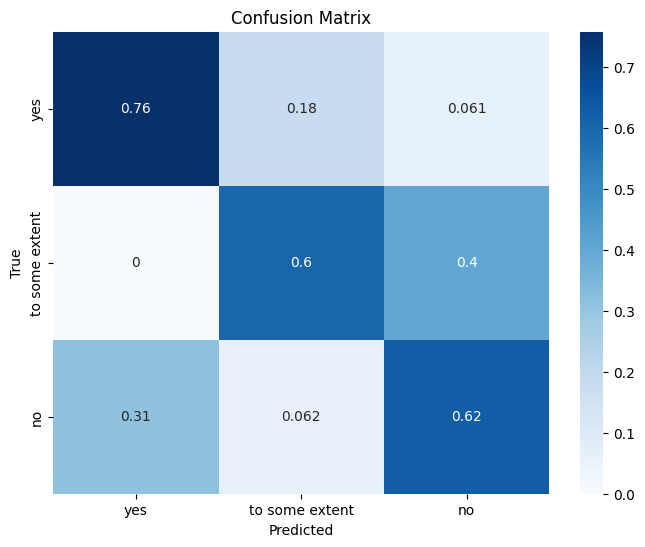

In [380]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

Confusion Matrix:


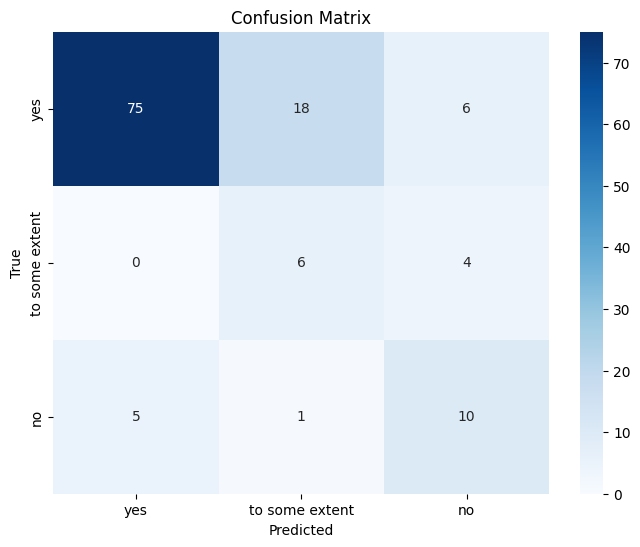

In [381]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

In [382]:
a =  "1. **Student Error Analysis:**\n   The student incorrectly calculated the sum of 12 and 3 as 13. The correct sum should be 15. This is a straightforward arithmetic error in addition.\n\n2. **Tutor Response Analysis:**\n   The tutor's response is: \"I appreciate your effort, but let's take another look at the question and work through it step-by-step to find the correct sum of 12 and 3.\" The tutor acknowledges the student's effort and suggests revisiting the problem to find the correct answer. However, the tutor does not explicitly point out the error or provide any specific guidance on how to correct it. The response is supportive but lacks specificity in addressing the mistake.\n\n3. **Pedagogical Effectiveness:**\n   The tutor's approach is polite and encourages the student to reconsider their calculation, which can promote self-correction. However, the feedback is somewhat vague and does not directly address the nature of the error. The student is not directly told what mistake was made, nor is there a clear explanation of how to proceed correctly. While the tutor's approach may help some students reflect, it may not be sufficient for students who need more explicit guidance to recognize and correct their misunderstanding.\n\n4. **Evaluation Justification:**\n   The response fits the \"To some extent\" label because the tutor hints at a mistake by suggesting a step-by-step review, indicating that the student's approach was flawed. However, the tutor does not clearly or explicitly identify the specific error, nor do they provide a concrete correction or targeted questioning to guide the student toward the correct method. The feedback is suggestive but not explicit, lacking the certainty and specificity required for a \"Yes\" label, but it is more than a complete miss or generic feedback, so \"No\" would not be appropriate."


In [383]:
print(a)

1. **Student Error Analysis:**
   The student incorrectly calculated the sum of 12 and 3 as 13. The correct sum should be 15. This is a straightforward arithmetic error in addition.

2. **Tutor Response Analysis:**
   The tutor's response is: "I appreciate your effort, but let's take another look at the question and work through it step-by-step to find the correct sum of 12 and 3." The tutor acknowledges the student's effort and suggests revisiting the problem to find the correct answer. However, the tutor does not explicitly point out the error or provide any specific guidance on how to correct it. The response is supportive but lacks specificity in addressing the mistake.

3. **Pedagogical Effectiveness:**
   The tutor's approach is polite and encourages the student to reconsider their calculation, which can promote self-correction. However, the feedback is somewhat vague and does not directly address the nature of the error. The student is not directly told what mistake was made, no